# Text-to-Shot: Joint Person-Camera Trajectory Generation

## via Conditional Flow Matching

---

This notebook demonstrates the **Text-to-Shot** pipeline end-to-end.

**Goal**: Given a text prompt, jointly generate:
1. **Person trajectory** (48, 3) — root position (px, py, pz)
2. **Camera trajectory** (48, 6) — position + orientation (tx, ty, tz, azimuth, elevation, roll)

**Method**: Conditional Flow Matching with a dual-branch Transformer denoiser (~24.7M params)

---

### Pipeline

```
1. Environment & Config
2. Data: 609k samples from E.T. + AMASS + HumanML3D
3. Data Exploration & Visualization
4. Model Architecture (Dual-Branch Transformer + Flow Matching)
5. Training
6. Inference / Generation
7. Evaluation
```

---
## 1. Environment & Config

In [2]:
import os, sys, json, yaml
import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Project root: /home/s5819307/Desktop/SEM/Text-to-Shot-main
PyTorch: 2.8.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 4080


In [3]:
# Load v9 config (Flow Matching, person_dim=3, 609k data)
with open('experiments/flow_matching/configs/v9.yaml', 'r') as f:
    config = yaml.safe_load(f)

model_cfg = config['model']
traj_cfg = config['trajectory']
data_cfg = config['data']

print('=== Model ===')
print(f'  person_dim: {model_cfg["person_dim"]}')
print(f'  camera_dim: {model_cfg["camera_dim"]}')
print(f'  hidden_dim: {model_cfg["hidden_dim"]}, layers: {model_cfg["num_layers"]}, heads: {model_cfg["num_heads"]}')
print(f'\n=== Trajectory ===')
print(f'  frames: {traj_cfg["default_num_frames"]} (2s @ 24fps)')
print(f'  motion types: {traj_cfg["motion_types"]}')
print(f'\n=== Data ===')
print(f'  data_root: {data_cfg["data_root"]}')
print(f'  norm_stats: {data_cfg["norm_stats_path"]}')

=== Model ===
  person_dim: 3
  camera_dim: 6
  hidden_dim: 256, layers: 6, heads: 4

=== Trajectory ===
  frames: 48 (2s @ 24fps)
  motion types: ['static', 'dolly-in', 'dolly-out', 'pan-left', 'pan-right', 'crane-up', 'crane-down', 'track', 'orbit']

=== Data ===
  data_root: /transfer/merged-v10
  norm_stats: /transfer/merged-v10/norm_stats_v9.json


---
## 2. Training Data: 609k Samples

Three complementary sources:

| Source | Samples | Person Data | Captions | Label Accuracy |
|--------|---------|-------------|----------|----------------|
| **E.T.** | 56,774 | SMPL-H tracking | Film captions | 99.7% (after trajectory-based verification) |
| **AMASS** | 476,820 | MoCap ground truth | Templates | 100% (deterministic rules) |
| **HumanML3D** | 75,859 | MoCap ground truth | Human-written | 100% |
| **Total** | **609,453** | | | |

### Data quality fixes applied to E.T.:
- **Label verification**: Caption-based labels (74% accuracy) replaced with trajectory-feature classification (99.7%)
- **SLAHMR jerk filtering**: Person jerk 8.3 → 0.51 (threshold = 1.0)
- **Look-at proxy removal**: 43% of samples had fake person positions (projected 3m in front of camera) — removed

In [4]:
# Load dataset
from src.data.dataset import JointTrajectoryDataset, collate_fn
from torch.utils.data import DataLoader

DATA_ROOT = data_cfg['data_root']
T = traj_cfg['default_num_frames']
p_dim = model_cfg['person_dim']
c_dim = model_cfg['camera_dim']

dataset = JointTrajectoryDataset(
    data_root=DATA_ROOT,
    split='train',
    num_frames=T,
    person_dim=p_dim,
    camera_dim=c_dim,
    index_file=data_cfg['train_index_file'],
    norm_stats_path=data_cfg['norm_stats_path'],
)

print(f'Training samples: {len(dataset)}')
print(f'Joint vector dim: {T * p_dim + T * c_dim} = {T}×{p_dim} (person) + {T}×{c_dim} (camera)')

Loaded norm stats from /transfer/merged-v10/norm_stats_v9.json (325091 samples)
Training samples: 325091
Joint vector dim: 432 = 48×3 (person) + 48×6 (camera)


---
## 3. Data Exploration

In [5]:
# Inspect a sample
sample = dataset[0]
print(f'Sample keys: {list(sample.keys())}')
print(f'  y shape: {sample["y"].shape}')
print(f'  text: "{sample.get("text", "N/A")[:80]}"')
print(f'  motion_type: {sample.get("motion_type", "N/A")}')
print(f'  shot_type: {sample.get("shot_type", "N/A")}')

# Denormalize for visualization
y = sample['y']
if dataset.norm_mean is not None:
    y = y * dataset.norm_std + dataset.norm_mean

person_total = T * p_dim
person_traj = y[:person_total].numpy().reshape(T, p_dim)
camera_traj = y[person_total:].numpy().reshape(T, c_dim)

print(f'\nPerson trajectory: shape={person_traj.shape}, range=[{person_traj.min():.2f}, {person_traj.max():.2f}]')
print(f'Camera trajectory: shape={camera_traj.shape}, range=[{camera_traj.min():.2f}, {camera_traj.max():.2f}]')

Sample keys: ['y', 'text', 'shot_type', 'motion_type', 'sample_id']
  y shape: torch.Size([432])
  text: "While the character moves backward and then left, the camera trucks left. Once t"
  motion_type: 1
  shot_type: 1

Person trajectory: shape=(48, 3), range=[-0.84, 0.29]
Camera trajectory: shape=(48, 6), range=[-1.53, 0.76]


In [7]:
# Motion type distribution
motion_counts = {}
inv_motion = {v: k for k, v in dataset.MOTION_TYPE_MAP.items()}
for i in range(min(len(dataset), 5000)):
    s = dataset[i]
    mt = inv_motion.get(s.get('motion_type', -1), 'unknown')
    motion_counts[mt] = motion_counts.get(mt, 0) + 1

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0d1117')
ax.set_facecolor('#161b22')
names = list(motion_counts.keys())
vals = [motion_counts[n] for n in names]
bars = ax.bar(names, vals, color='#58a6ff')
ax.set_title('Motion Type Distribution (first 5000 samples)', color='white', fontsize=13)
ax.tick_params(colors='gray', rotation=45)
for spine in ax.spines.values(): spine.set_color('#30363d')
plt.tight_layout()
plt.savefig('/tmp/motion_dist.png', dpi=120, facecolor=fig.get_facecolor())
plt.show()

/tmp/ipykernel_2272453/181164983.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 4. Model Architecture

### Dual-Branch Transformer Denoiser

```
Conditioning (768d):
  CLIP text embedding (512d) + timestep (128d) + shot type (64d) + motion type (64d)

Dual-Branch Transformer (6 layers, 256 hidden, 4 heads):
  Each layer:
    1. Self-Attention (person branch / camera branch independently)
    2. Cross-Attention (person ↔ camera, bidirectional)
    3. FiLM-conditioned FFN (conditioning injected via scale+shift)

Output: velocity field v_θ(x_t, t, c)
```

### Conditional Flow Matching (OT-CFM)

- Forward: `x_t = (1-t)ε + t·x_0` (straight-line interpolation, t∈[0,1])
- Target: `v = x_0 - ε`
- Loss: `||v_θ - v||² + λ·smoothness` (λ=0.08)
- Sampling: 50 Euler ODE steps, CFG with 25% text dropout

In [8]:
# Build the model
from src.models.denoiser import JointTrajectoryDenoiser
from experiments.flow_matching.models.flow_model import ConditionalFlowMatching

device = 'cuda' if torch.cuda.is_available() else 'cpu'

denoiser = JointTrajectoryDenoiser(
    person_dim=p_dim,
    camera_dim=c_dim,
    num_frames=T,
    hidden_dim=model_cfg['hidden_dim'],
    num_layers=model_cfg['num_layers'],
    num_heads=model_cfg['num_heads'],
    text_dim=512,
    timestep_dim=128,
    num_shot_types=len(config['shot_types']['categories']),
    shot_type_dim=config['shot_types']['embedding_dim'],
    num_motion_types=len(traj_cfg['motion_types']),
    motion_type_dim=traj_cfg.get('motion_type_dim', 64),
    dropout=0.0,
).to(device)

flow = ConditionalFlowMatching(denoiser=denoiser).to(device)

total_params = sum(p.numel() for p in flow.parameters())
trainable = sum(p.numel() for p in flow.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,} ({total_params/1e6:.1f}M)')
print(f'Trainable: {trainable:,}')

Total parameters: 24,702,473 (24.7M)
Trainable: 24,702,473


In [9]:
# Visualize flow matching interpolation (noise → data)
fig, axes = plt.subplots(1, 5, figsize=(18, 3), facecolor='#0d1117')
x0 = torch.randn(1, T * p_dim + T * c_dim)  # noise at t=0
x1 = sample['y'].unsqueeze(0)  # clean data at t=1

for i, t_val in enumerate([0.0, 0.25, 0.5, 0.75, 1.0]):
    xt = (1 - t_val) * x0 + t_val * x1  # straight-line interpolation
    ax = axes[i]
    ax.set_facecolor('#161b22')
    ax.plot(xt[0, :T*p_dim].numpy(), color='#4ECDC4', alpha=0.8, linewidth=0.8)
    ax.plot(xt[0, T*p_dim:].numpy(), color='#FFE66D', alpha=0.8, linewidth=0.8)
    ax.set_title(f't = {t_val}', color='white', fontsize=11)
    ax.tick_params(colors='gray', labelsize=7)
    for spine in ax.spines.values(): spine.set_color('#30363d')

fig.suptitle('Flow Matching: straight-line interpolation from noise (t=0) to data (t=1)',
             color='white', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2272453/1238379529.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 5. Training

Training configuration:
- **Optimizer**: AdamW (lr=1e-4, cosine decay, 10-epoch warmup)
- **Epochs**: 250, batch size 64
- **Loss**: Flow matching velocity + smoothness regularization (λ=0.08)
- **CFG**: 25% text dropout
- **Hardware**: NVIDIA RTX 4080 (16 GB)

### Key findings:
- **DDPM collapsed** on all configurations (mode collapse regardless of motion type)
- **Flow Matching** produced the first motion differentiation
- **Timestep convention**: FM t=0 is noise, but Transformer sinusoidal embedding expects t=0 = clean → must reverse with `t_int = (1-t) × 999`

In [10]:
# Training commands
print('=== Train from command line ===')
print()
print('PYTHONPATH=. python experiments/flow_matching/train.py \\')
print('    --config experiments/flow_matching/configs/v9.yaml \\')
print('    --device cuda')
print()
print('=== Resume from checkpoint ===')
print()
print('PYTHONPATH=. python experiments/flow_matching/train.py \\')
print('    --config experiments/flow_matching/configs/v9.yaml \\')
print('    --resume /transfer/fm-v10-checkpoints/fm_epoch100.pth \\')
print('    --device cuda')

=== Train from command line ===

PYTHONPATH=. python experiments/flow_matching/train.py \
    --config experiments/flow_matching/configs/v9.yaml \
    --device cuda

=== Resume from checkpoint ===

PYTHONPATH=. python experiments/flow_matching/train.py \
    --config experiments/flow_matching/configs/v9.yaml \
    --resume /transfer/fm-v10-checkpoints/fm_epoch100.pth \
    --device cuda


---
## 6. Inference / Generation

Load a trained checkpoint and generate trajectories from text prompts.

**Process**:
1. Encode text with CLIP → 512d embedding
2. Start from noise x₀ ~ N(0, I)
3. Euler ODE integration: 50 steps from t=0 (noise) to t=1 (clean)
4. Denormalize + smooth + visualize

In [11]:
# Load trained checkpoint
from experiments.flow_matching.generate import (
    load_model, smooth_trajectory, regularize_person_trajectory,
    freeze_static_dims, SHOT_TYPE_MAP, MOTION_TYPE_MAP,
)
from generate import visualize_joint

CHECKPOINT = '/transfer/fm-v10-checkpoints/fm_best.pth'
# Fallback
if not os.path.exists(CHECKPOINT):
    CHECKPOINT = '/transfer/fm-v10-checkpoints/fm_final.pth'

flow_model, ckpt_config = load_model(CHECKPOINT, device)
print(f'Loaded: {CHECKPOINT}')

# Text encoder
from src.models.text_encoder import CLIPTextEncoder
text_encoder = CLIPTextEncoder(
    model_name=config['text_encoder']['model_name'], device=device
).to(device)
print('CLIP text encoder loaded.')

# Norm stats
norm_stats_path = data_cfg['norm_stats_path']
with open(norm_stats_path) as f:
    stats = json.load(f)
norm_mean = torch.tensor(stats['mean'], dtype=torch.float32, device=device)
norm_std = torch.tensor(stats['std'], dtype=torch.float32, device=device)
print(f'Norm stats: {norm_stats_path}')

Loaded: /transfer/fm-v10-checkpoints/fm_best.pth
CLIP text encoder loaded.
Norm stats: /transfer/merged-v10/norm_stats_v9.json


In [12]:
@torch.no_grad()
def generate_and_visualize(text, motion='static', shot='medium-shot',
                           guidance_scale=3.0, num_steps=50):
    """Generate a trajectory from text and display the visualization."""
    text_embed = text_encoder([text])
    shot_t = torch.tensor([SHOT_TYPE_MAP.get(shot, 1)], device=device)
    motion_t = torch.tensor([MOTION_TYPE_MAP.get(motion, 0)], device=device)

    y = flow_model.sample(text_embed, shot_type=shot_t, motion_type=motion_t,
                          device=device, guidance_scale=guidance_scale,
                          num_steps=num_steps)
    y = y * norm_std + norm_mean
    y_np = y[0].cpu().numpy()

    person_total = T * p_dim
    person_traj = y_np[:person_total].reshape(T, p_dim)
    camera_traj = y_np[person_total:].reshape(T, c_dim)

    # Post-process
    pw = min(31, T if T % 2 == 1 else T - 1)
    person_traj = smooth_trajectory(person_traj, window=pw)
    person_traj = regularize_person_trajectory(person_traj, static_threshold=0.08, segment_cost=0.3)
    person_traj = freeze_static_dims(person_traj, threshold=0.05)
    camera_traj = smooth_trajectory(camera_traj, window=21, angle_dims=[3,4,5], angle_window=31)
    camera_traj = freeze_static_dims(camera_traj, threshold=0.05)

    save_path = f'/tmp/gen_{motion}.png'
    visualize_joint(person_traj, camera_traj, text, motion, save_path=save_path)

    from IPython.display import Image, display
    display(Image(filename=save_path, width=900))
    return person_traj, camera_traj

/home/s5819307/Desktop/SEM/Text-to-Shot-main/generate.py:287: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  tri = plt.Polygon(


Visualization saved to /tmp/gen_static.png


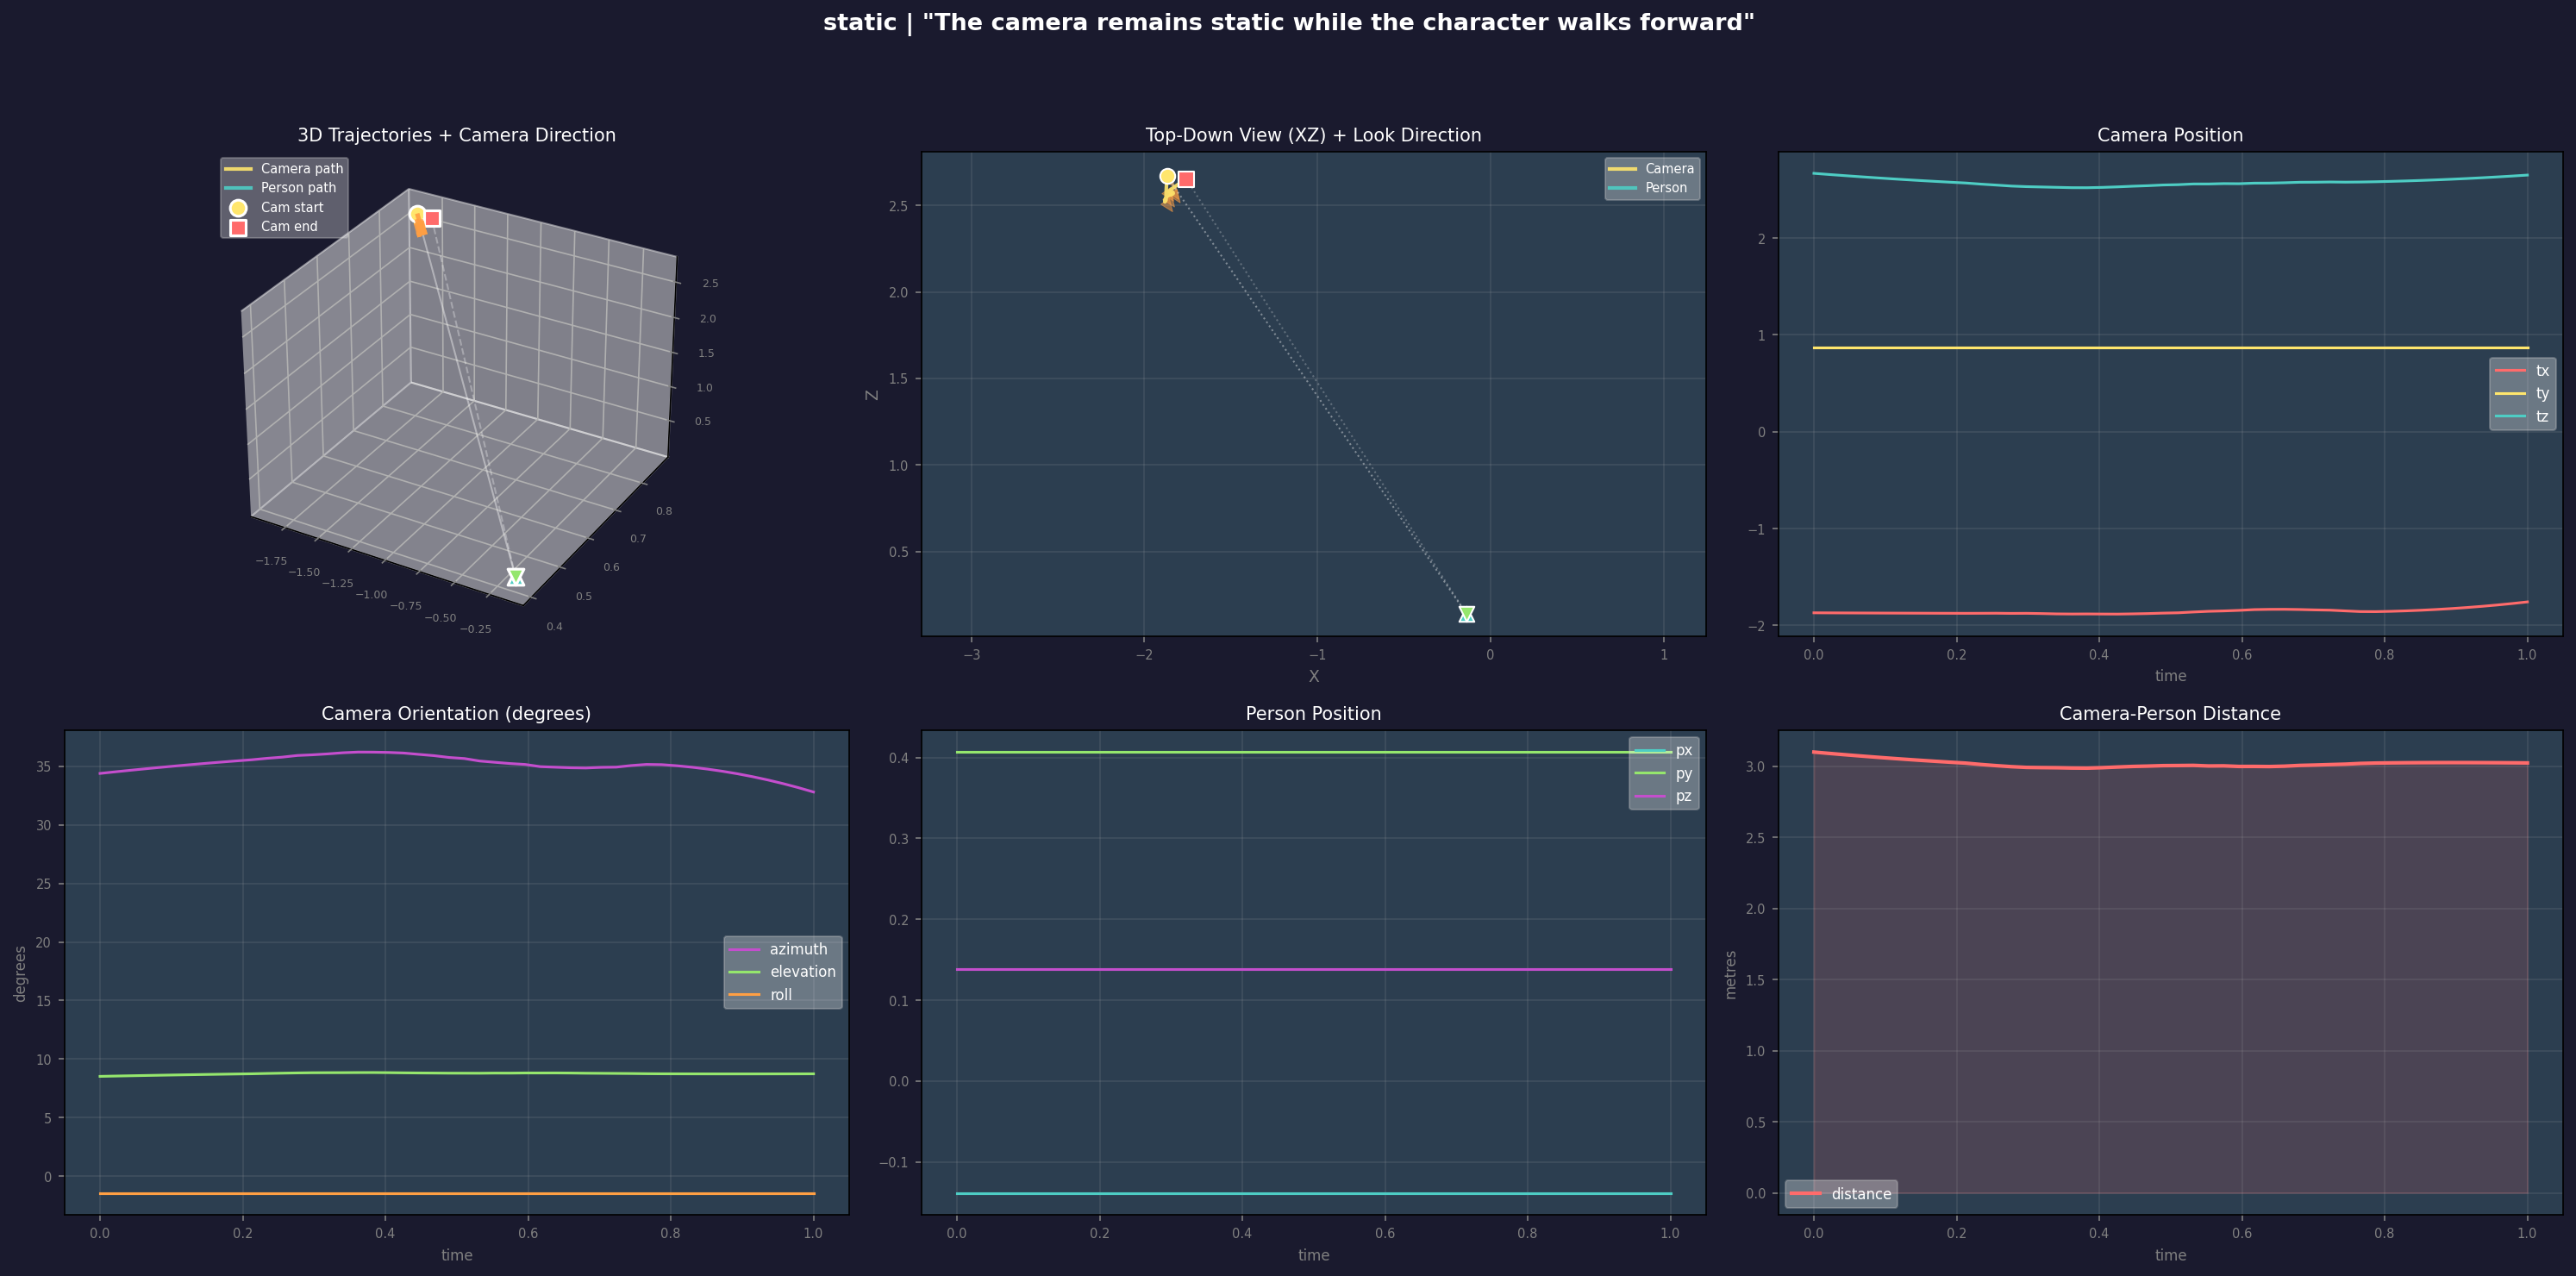

In [13]:
# Generate: Static
generate_and_visualize(
    'The camera remains static while the character walks forward',
    motion='static'
);

Visualization saved to /tmp/gen_dolly-in.png


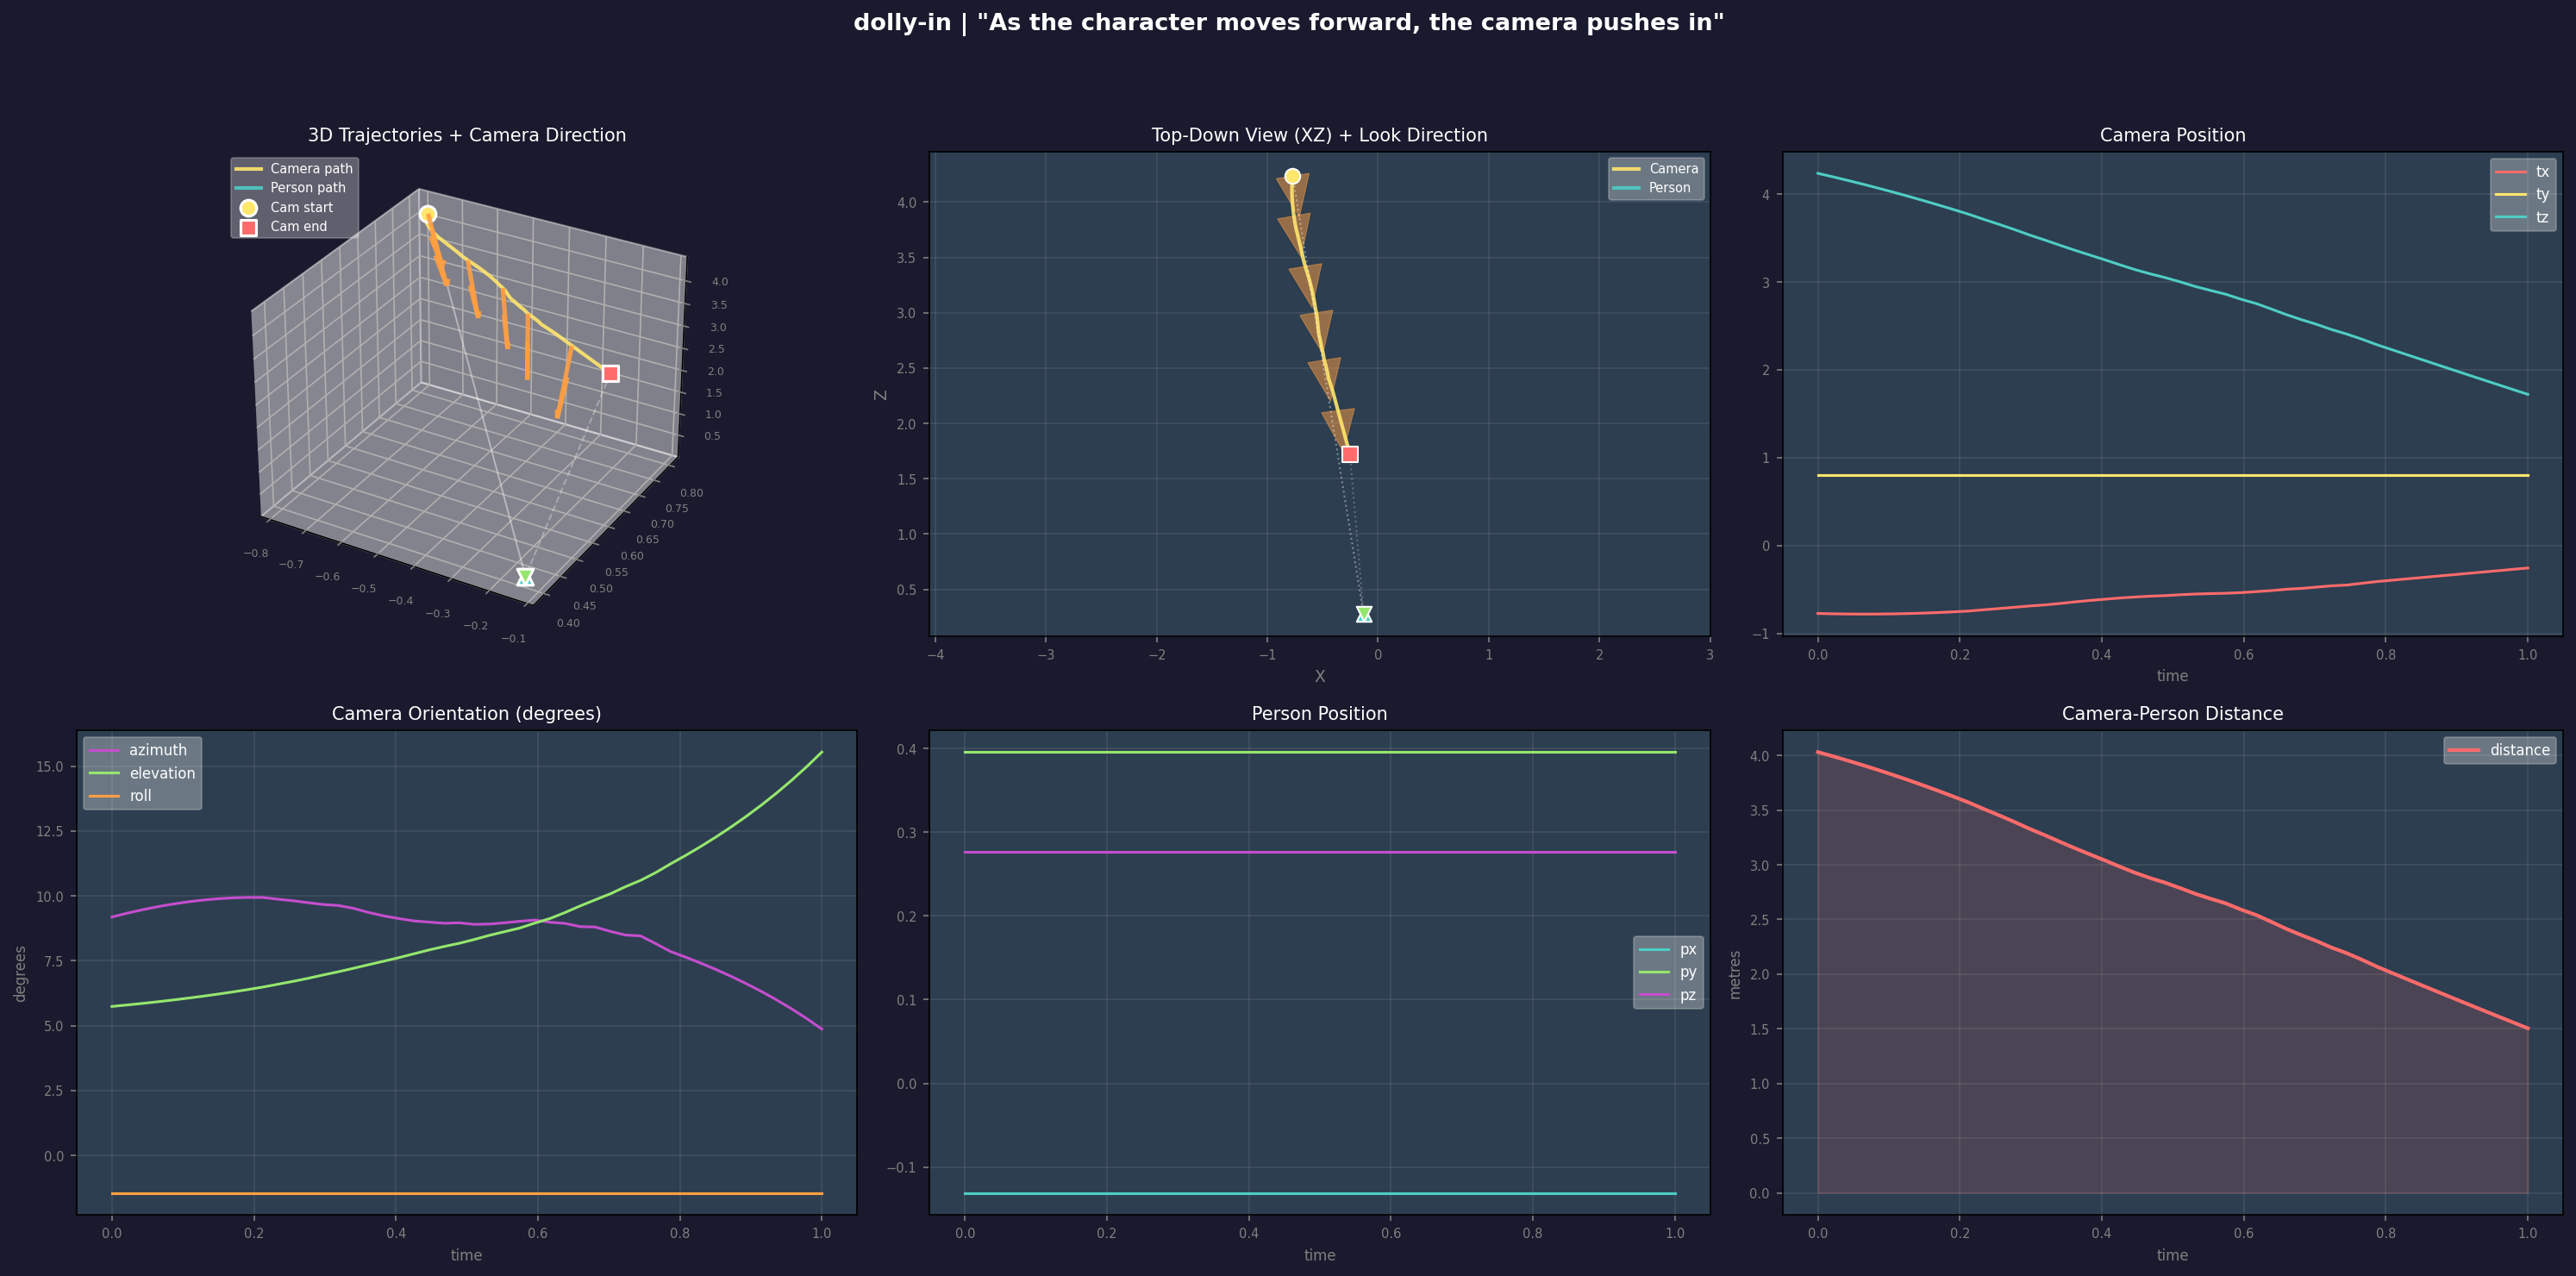

In [14]:
# Generate: Dolly-in
generate_and_visualize(
    'As the character moves forward, the camera pushes in',
    motion='dolly-in'
);

Visualization saved to /tmp/gen_dolly-out.png


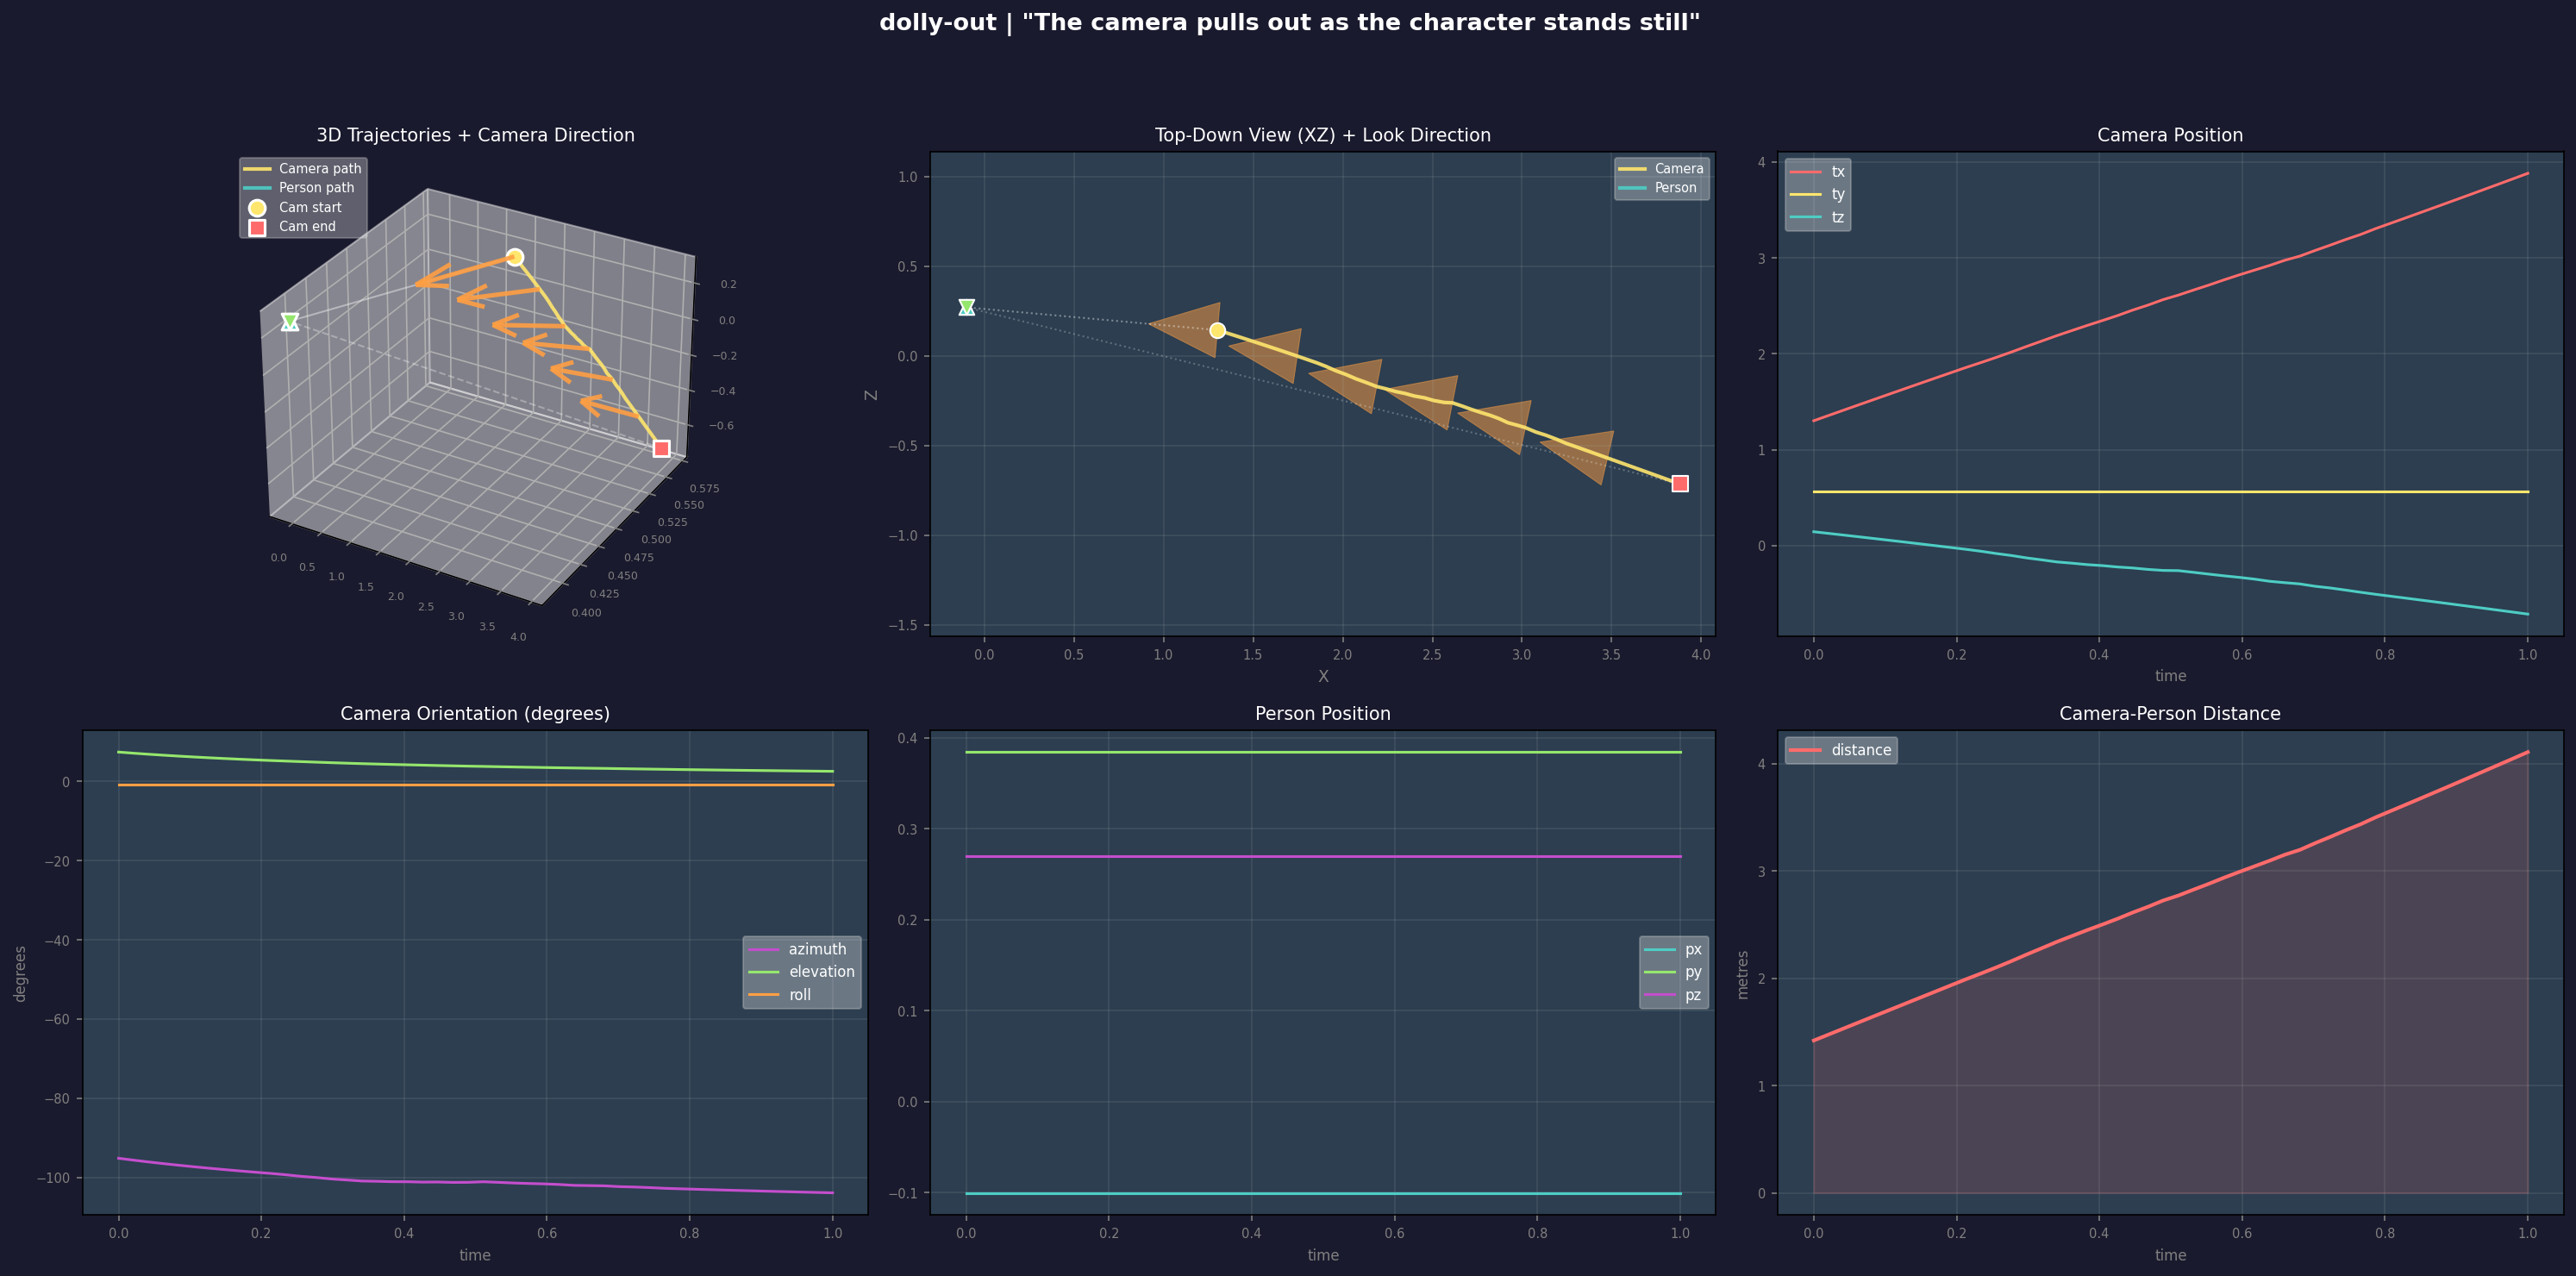

In [15]:
# Generate: Dolly-out
generate_and_visualize(
    'The camera pulls out as the character stands still',
    motion='dolly-out'
);

Visualization saved to /tmp/gen_pan-left.png


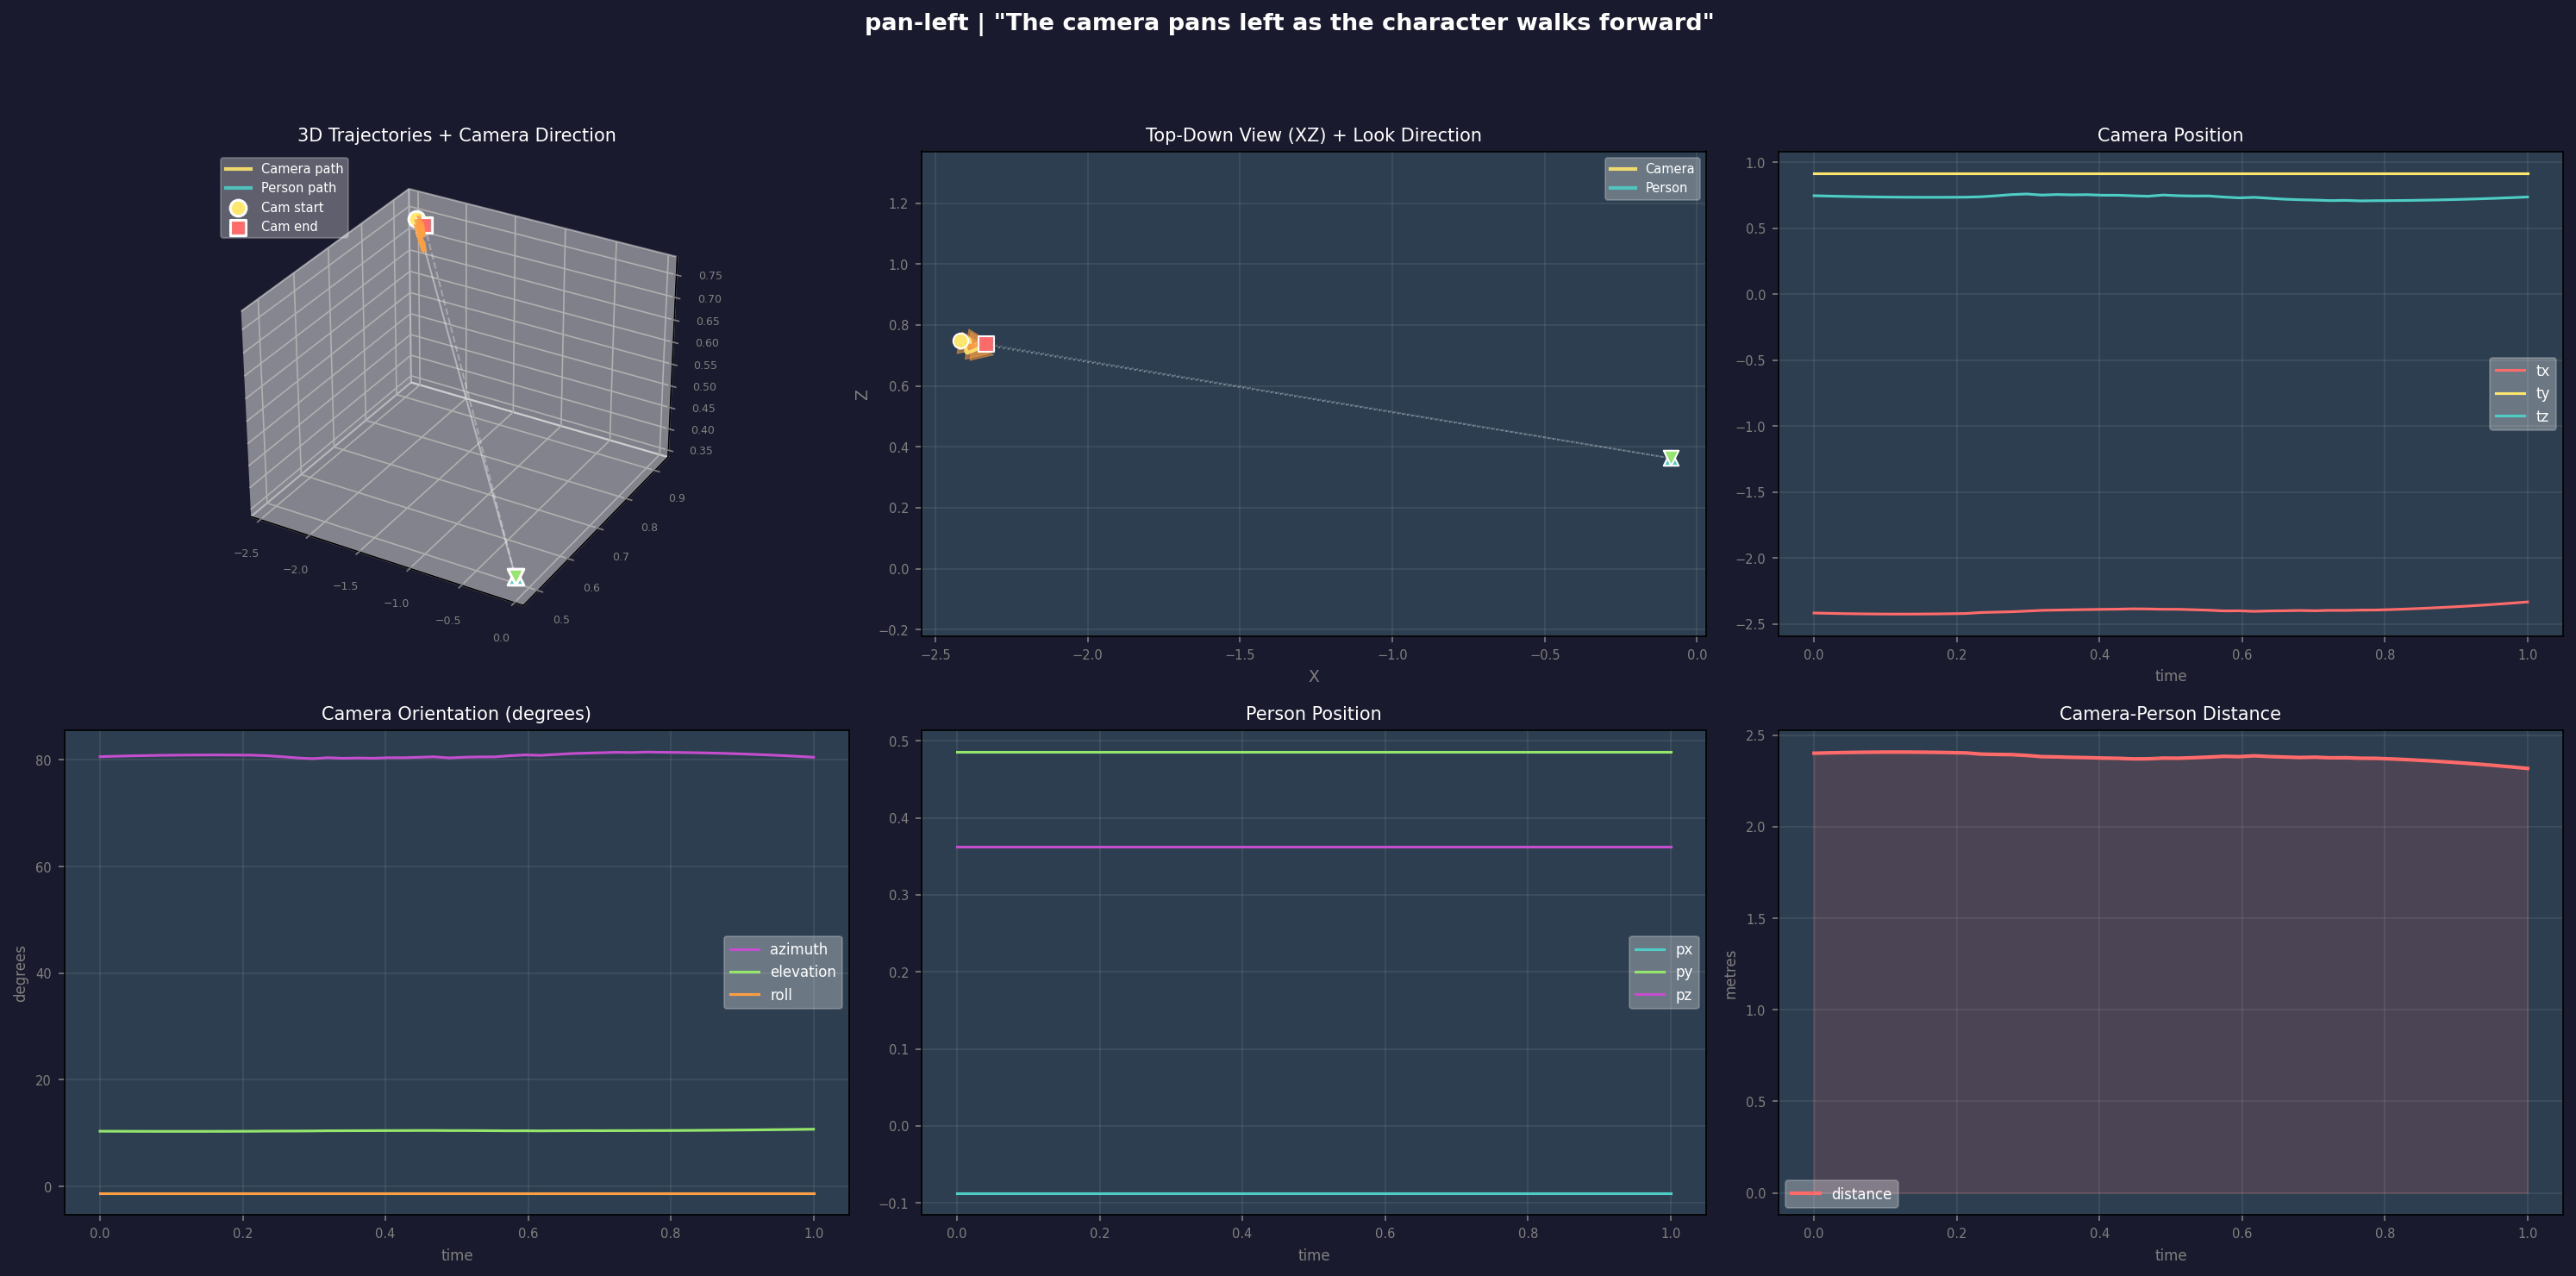

In [16]:
# Generate: Pan left
generate_and_visualize(
    'The camera pans left as the character walks forward',
    motion='pan-left'
);

Visualization saved to /tmp/gen_orbit.png


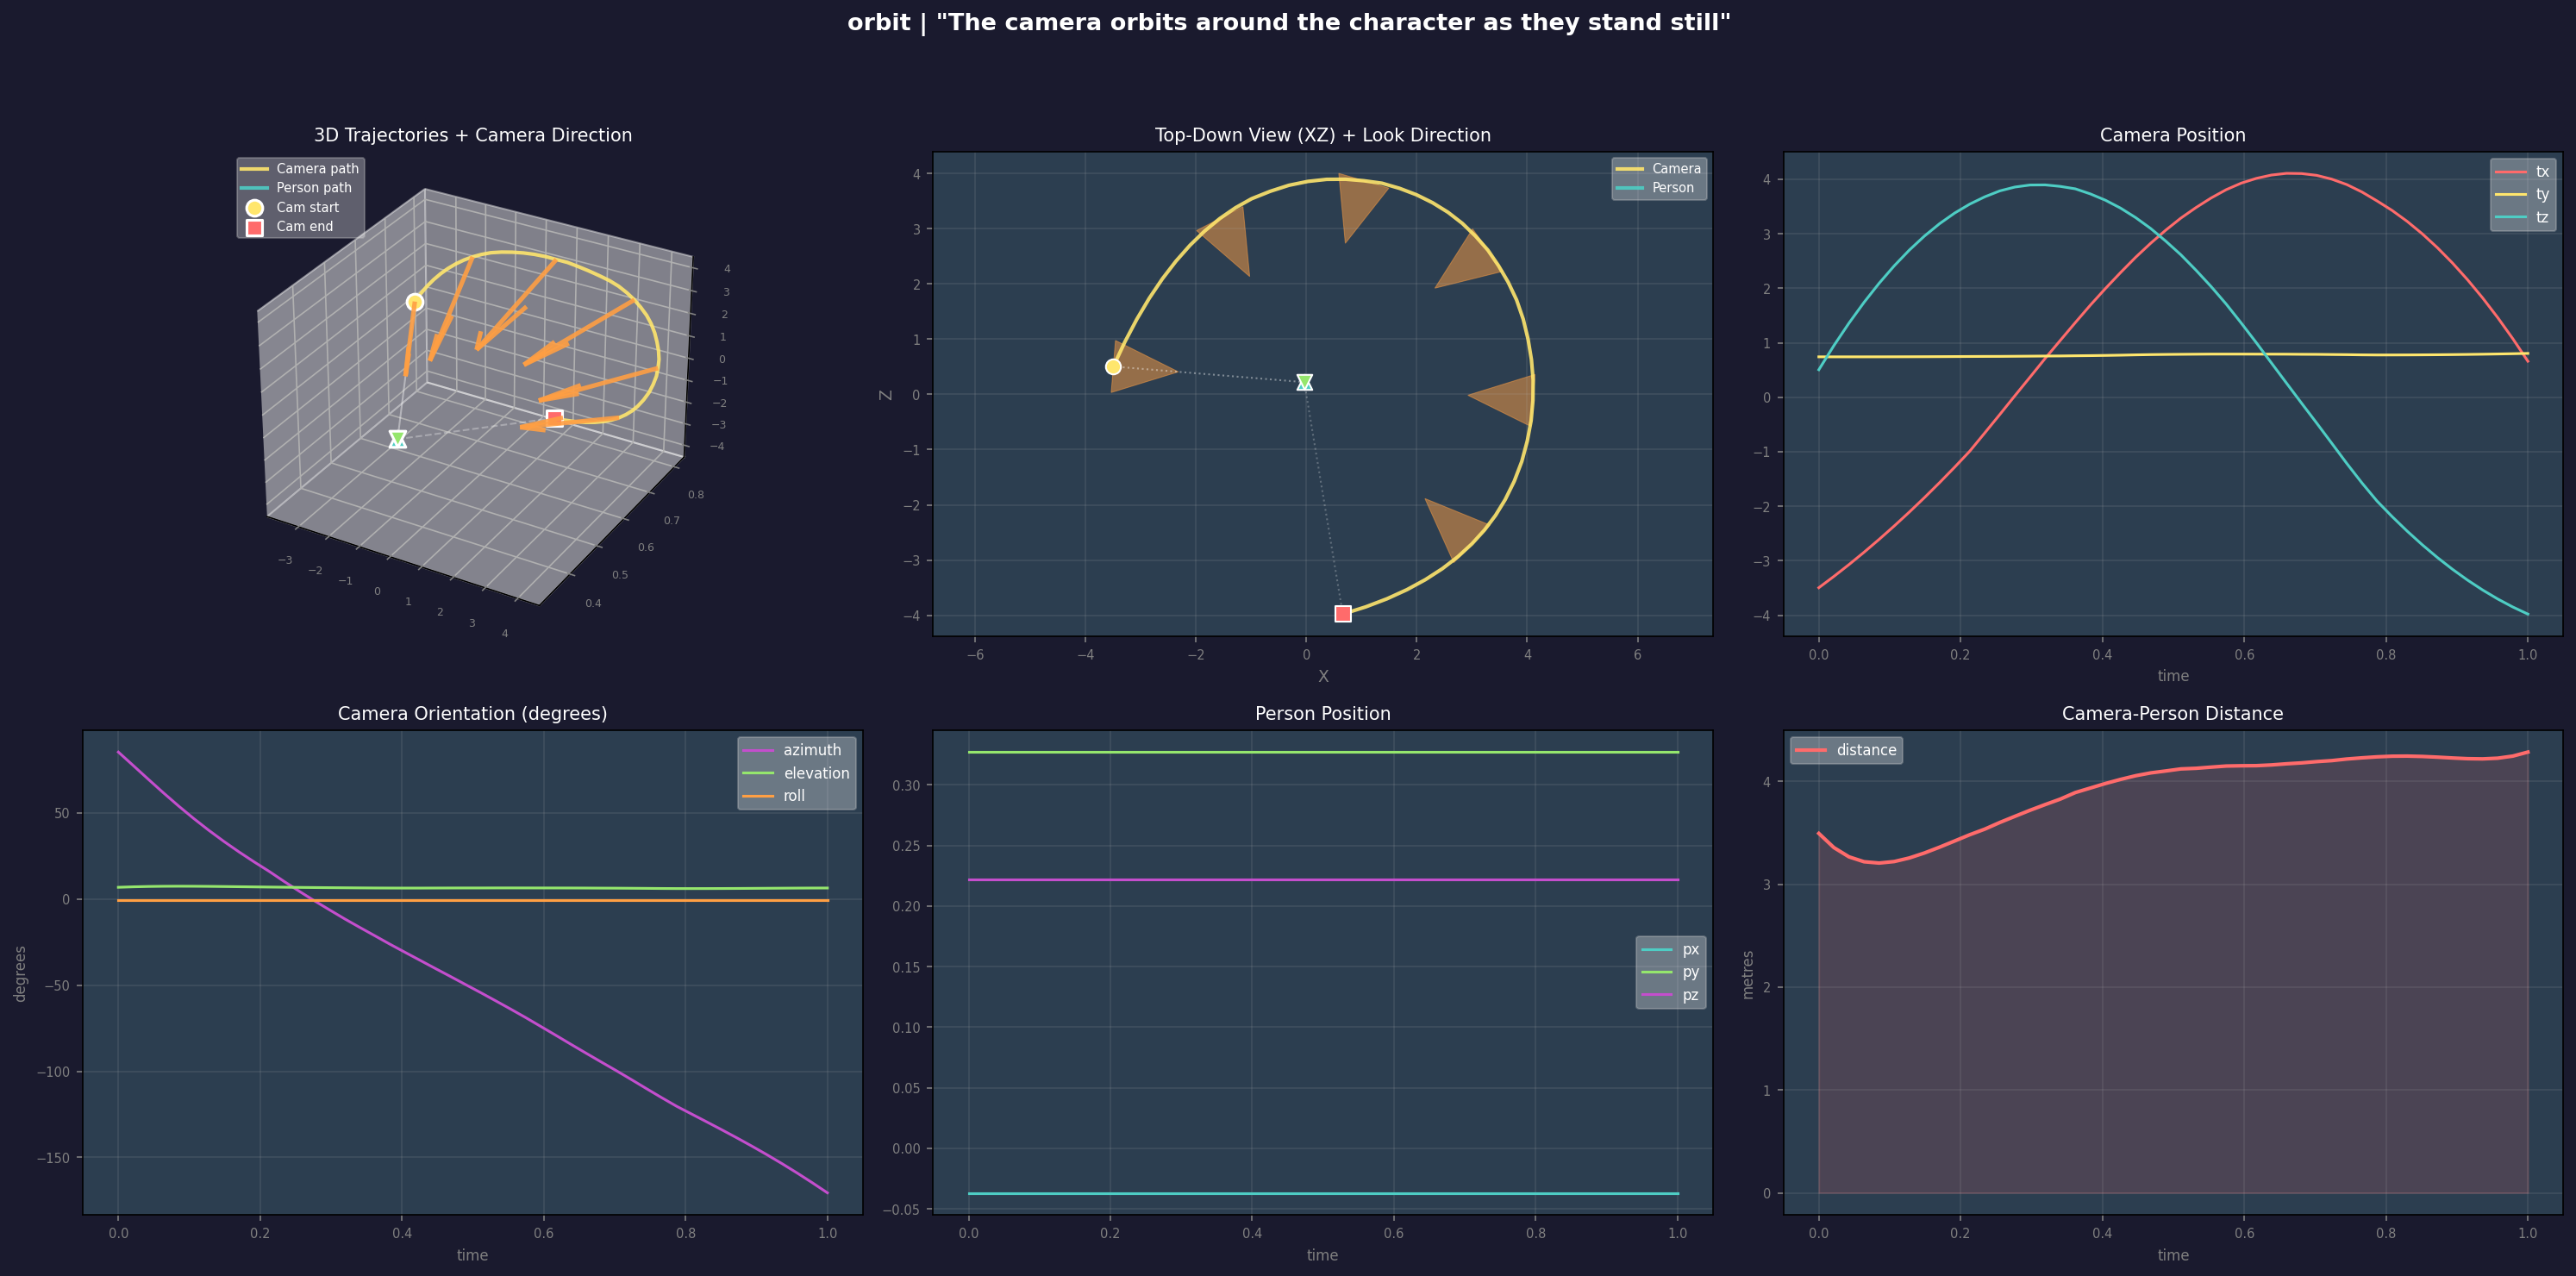

In [17]:
# Generate: Orbit
generate_and_visualize(
    'The camera orbits around the character as they stand still',
    motion='orbit'
);

Visualization saved to /tmp/gen_crane-up.png


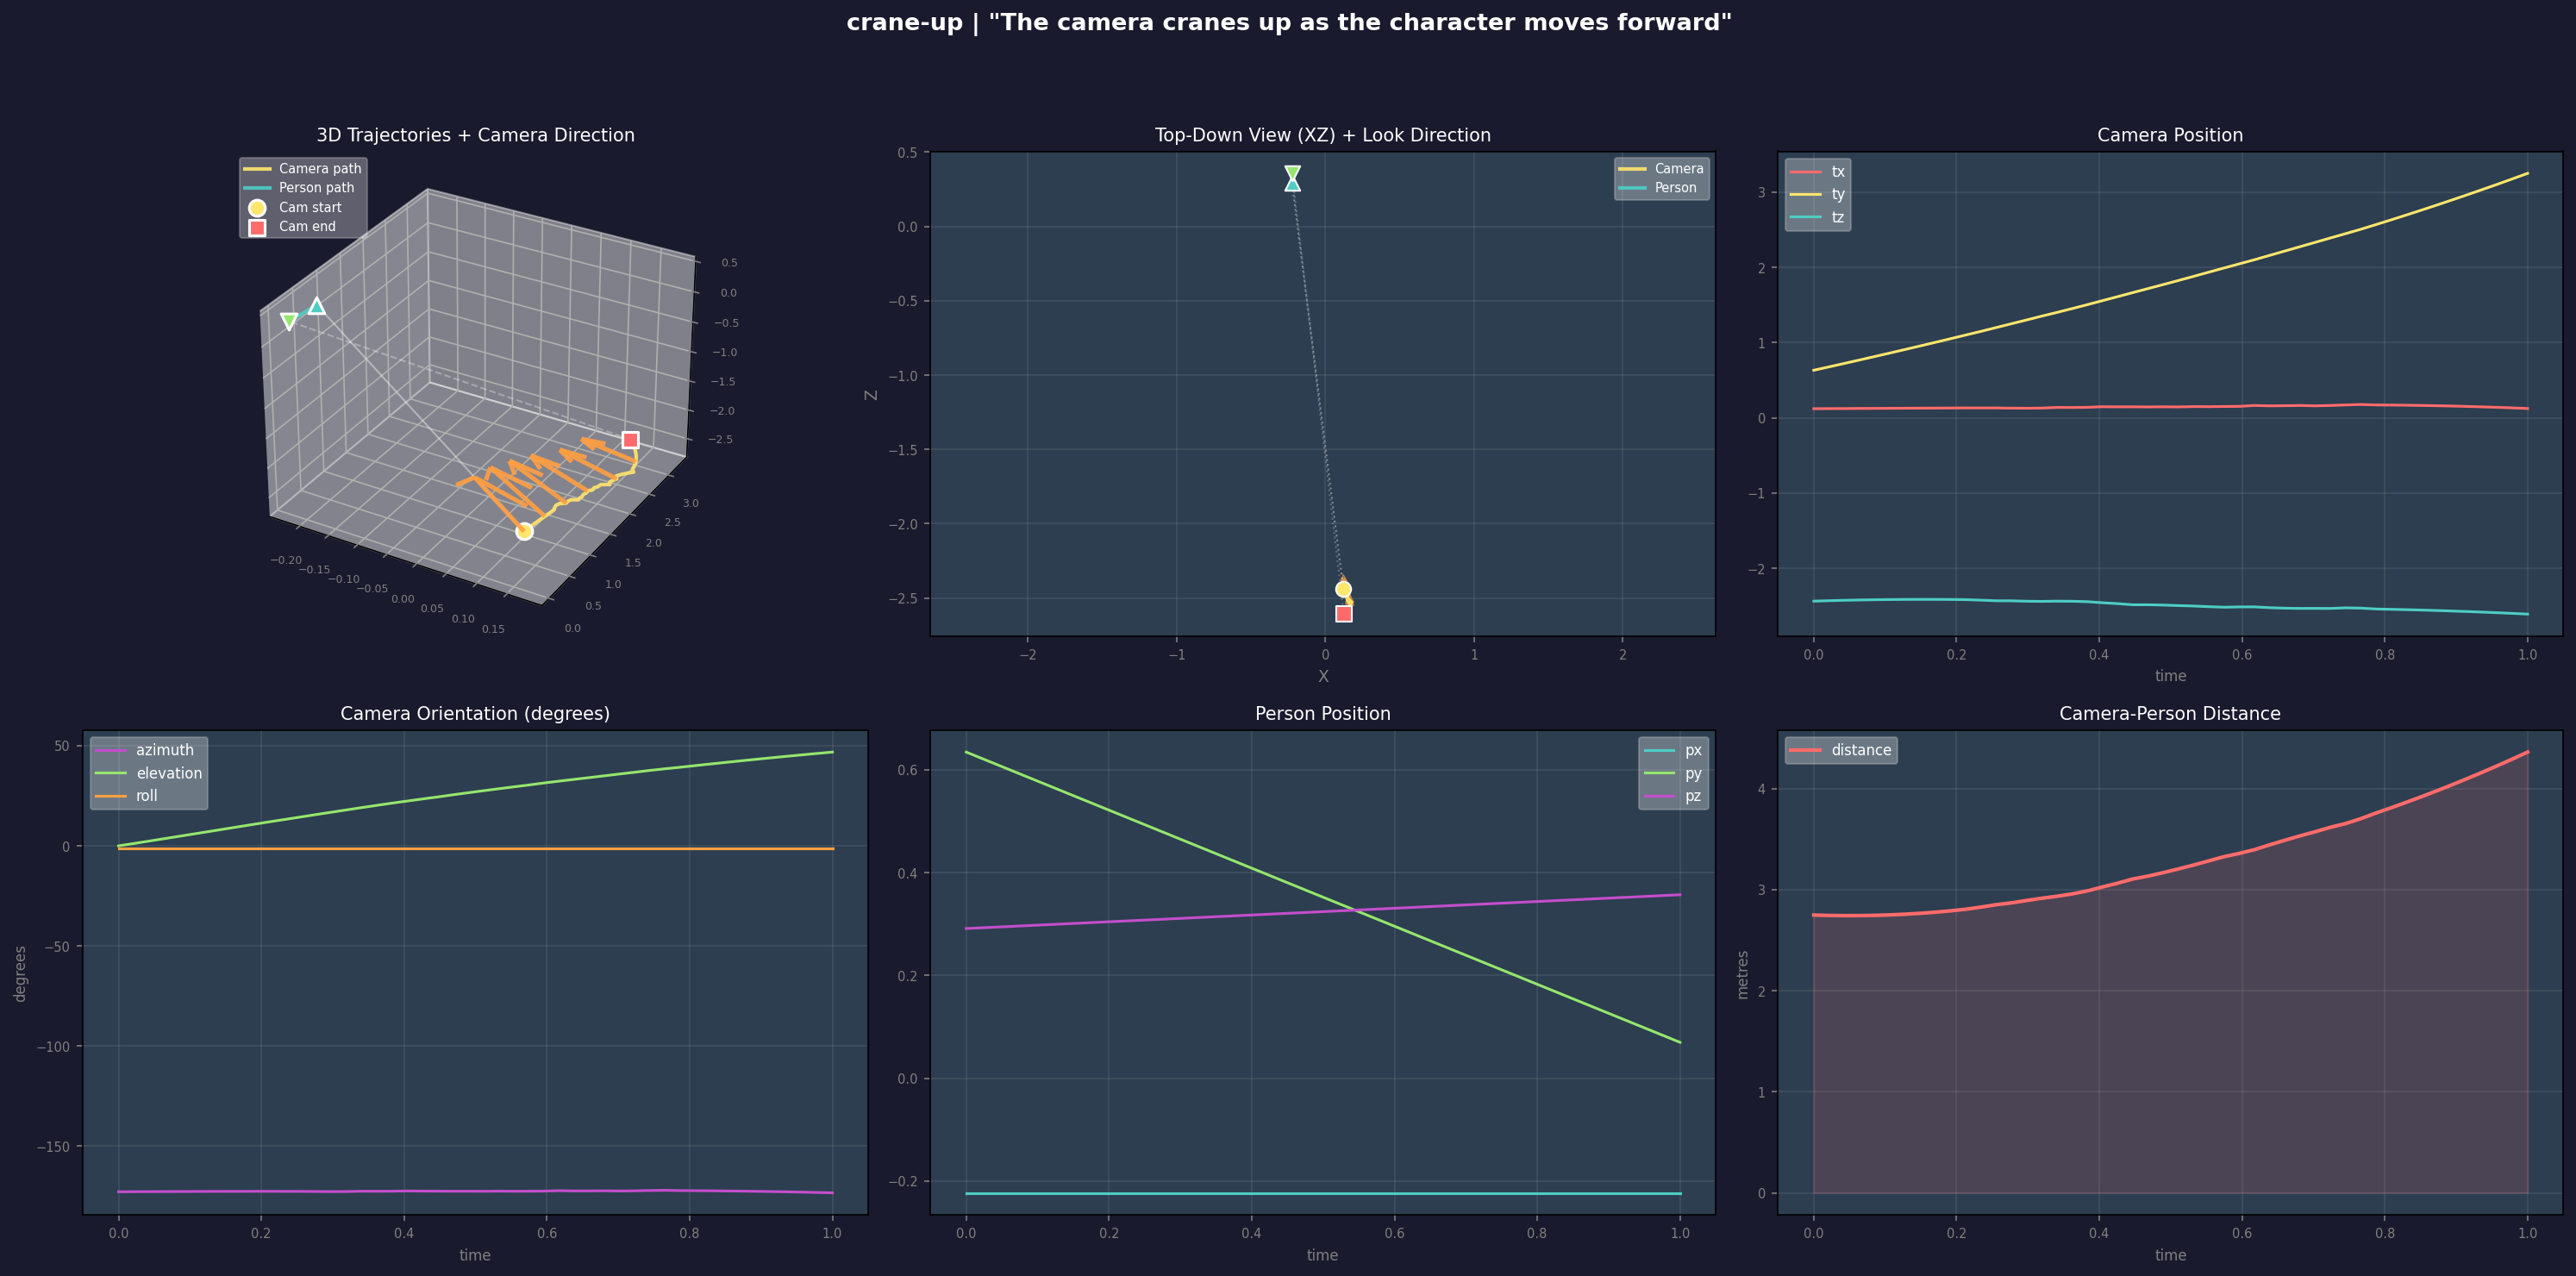

In [18]:
# Generate: Crane up
generate_and_visualize(
    'The camera cranes up as the character moves forward',
    motion='crane-up'
);

Visualization saved to /tmp/gen_track.png


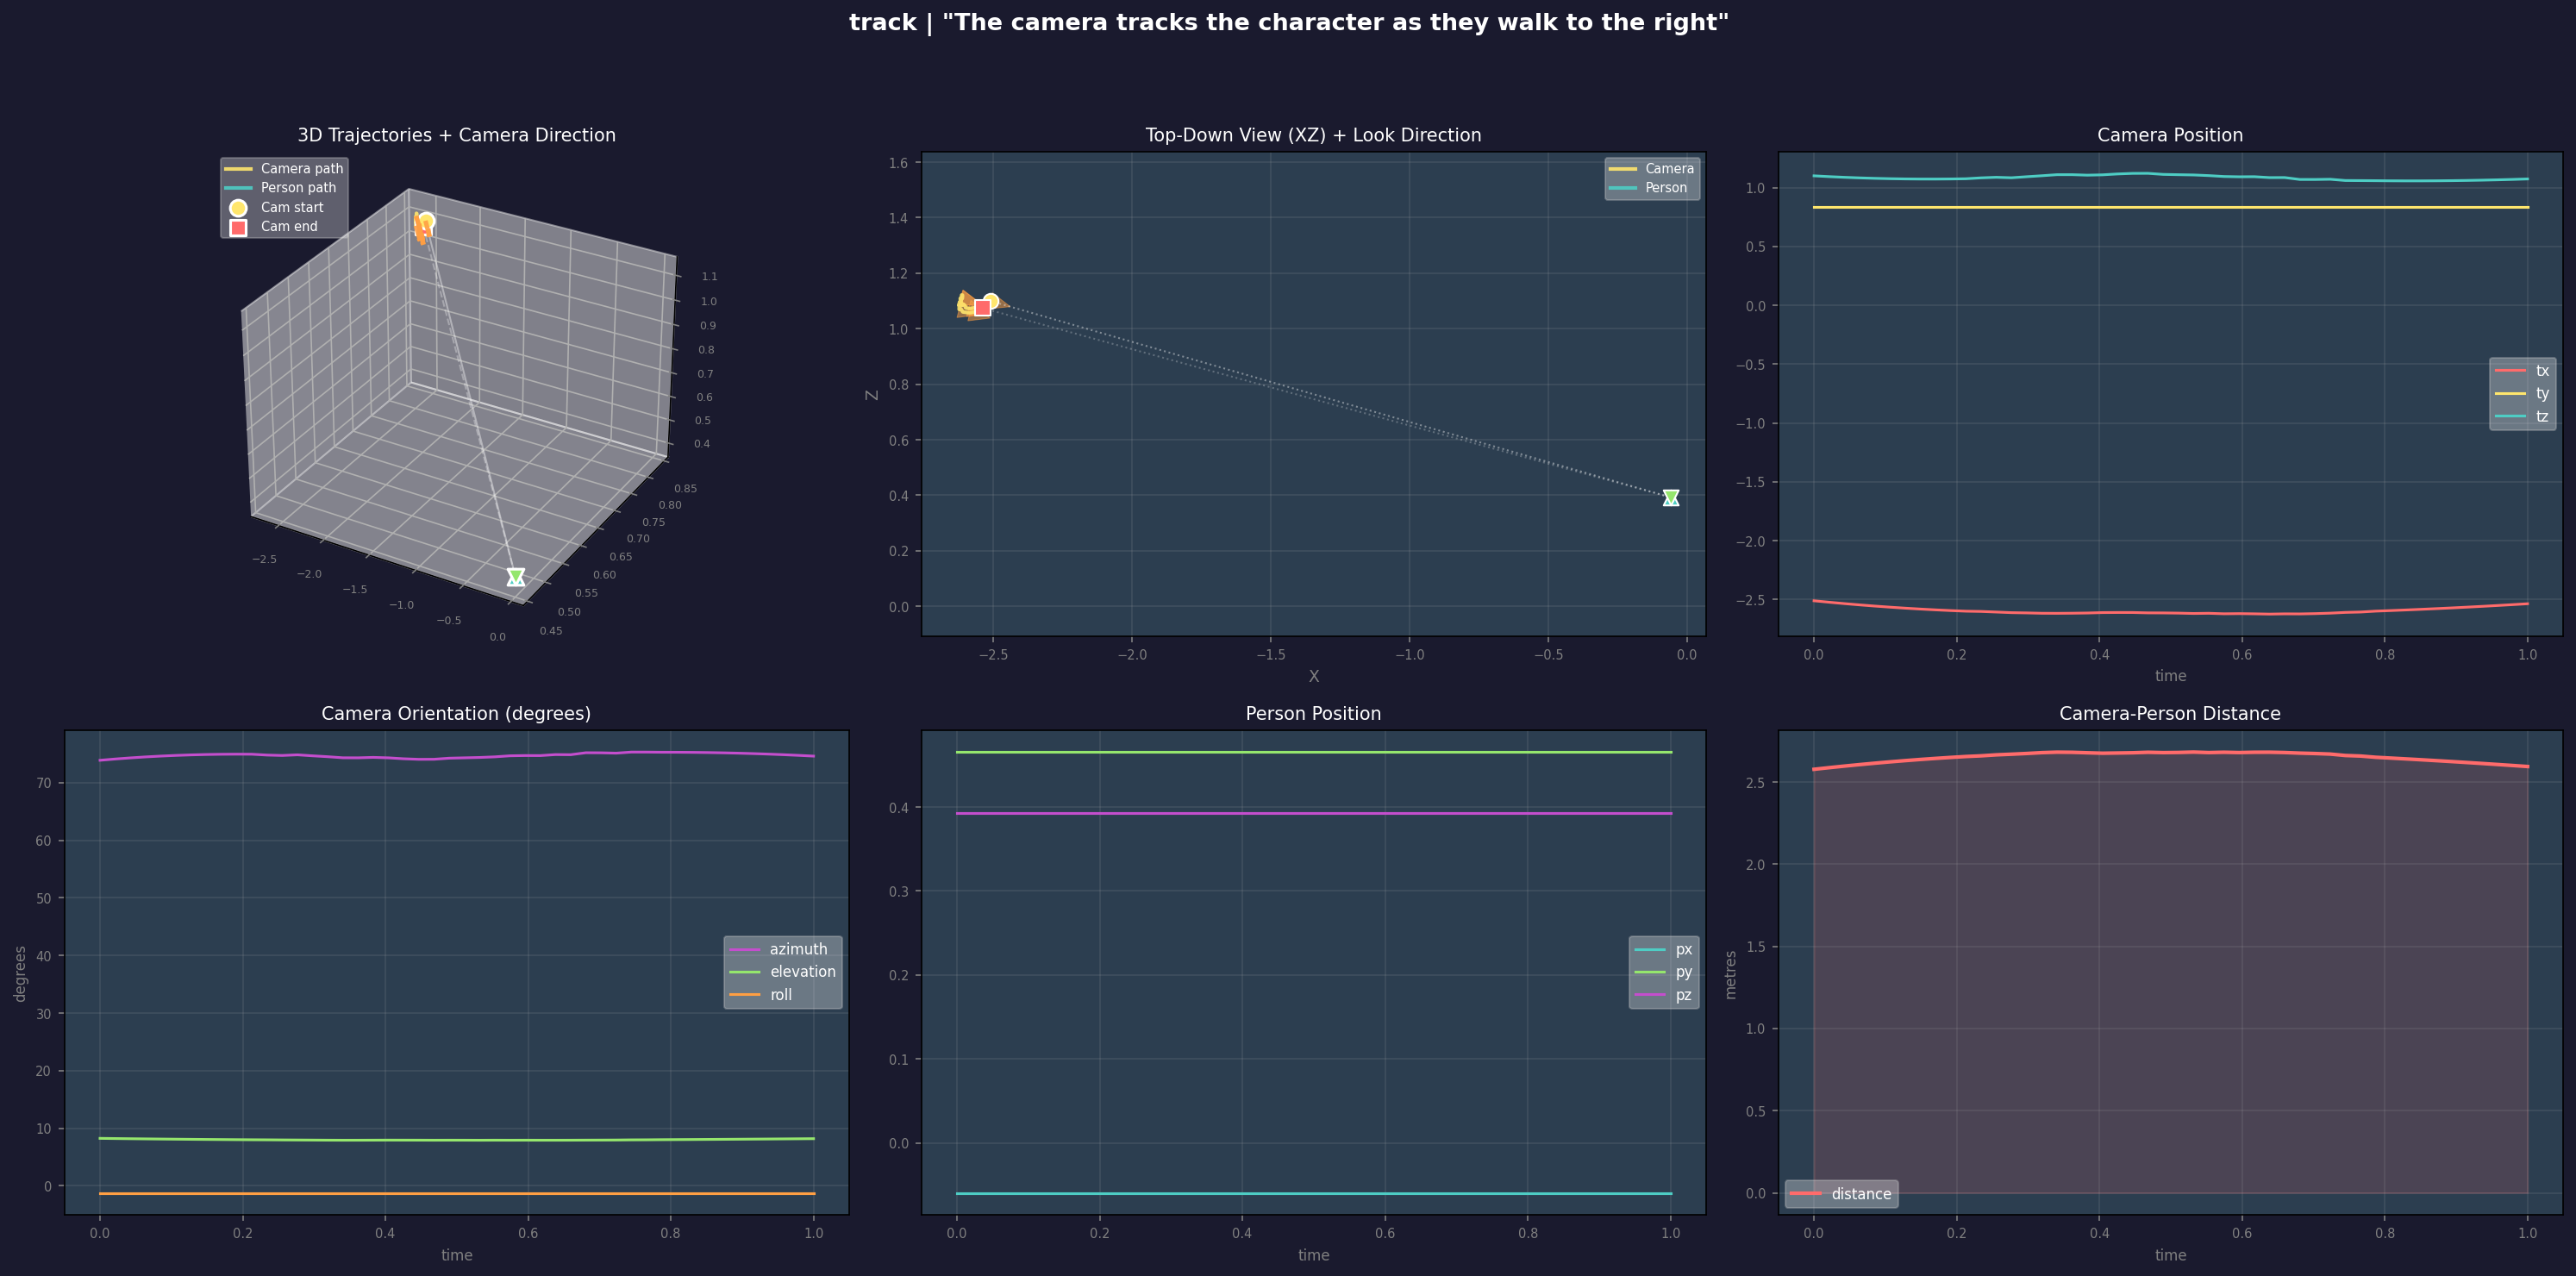

In [19]:
# Generate: Track
generate_and_visualize(
    'The camera tracks the character as they walk to the right',
    motion='track'
);

---
## 7. Evaluation

Metrics:
- **FTD** (Frechet Trajectory Distance): distribution similarity to ground truth
- **Motion Type Accuracy**: does generated trajectory match the requested motion?
- **Smoothness (Jerk)**: lower = smoother camera
- **Distance Monotonicity**: for dolly-in/out, is distance consistently changing?

In [20]:
# Run evaluation from command line
print('=== Evaluate ===')
print()
print('PYTHONPATH=. python experiments/flow_matching/evaluate.py \\')
print(f'    --checkpoint {CHECKPOINT} \\')
print('    --device cuda --max-samples 1000')

=== Evaluate ===

PYTHONPATH=. python experiments/flow_matching/evaluate.py \
    --checkpoint /transfer/fm-v10-checkpoints/fm_best.pth \
    --device cuda --max-samples 1000


In [21]:
# Load evaluation results if available
eval_path = config['paths']['output_dir'] + '/evaluation_results.json'
if os.path.exists(eval_path):
    with open(eval_path) as f:
        results = json.load(f)

    print('=' * 60)
    print('  EVALUATION RESULTS')
    print('=' * 60)
    print(f'\n[1] Frechet Trajectory Distance (FTD)')
    print(f'  Joint FTD:  {results["ftd_joint"]:.2f}')
    print(f'  Person FTD: {results["ftd_person"]:.2f}')
    print(f'  Camera FTD: {results["ftd_camera"]:.2f}')
    print(f'\n[2] Motion Type Accuracy: {results["motion_type_accuracy"]:.1f}%')
    if 'per_motion_accuracy' in results:
        for mt, acc in results['per_motion_accuracy'].items():
            flag = ' !!!' if acc < 30 else ''
            print(f'  {mt:15s}: {acc:5.1f}%{flag}')
    print(f'\n[3] Smoothness')
    print(f'  Gen camera jerk: {results["camera_jerk_mean"]:.4f}')
    print(f'  GT  camera jerk: {results["gt_camera_jerk_mean"]:.4f}')
    print(f'  Gen person jerk: {results["person_jerk_mean"]:.4f}')
    print(f'\n[4] Camera-Person Distance: {results.get("cam_person_dist_mean", 0):.2f}m')
    print(f'\nSamples: {results["num_samples"]}, Guidance: {results["guidance_scale"]}')
else:
    print(f'No evaluation results found at {eval_path}')
    print('Run the evaluate command above first.')

  EVALUATION RESULTS

[1] Frechet Trajectory Distance (FTD)
  Joint FTD:  590.88
  Person FTD: 20.45
  Camera FTD: 568.64

[2] Motion Type Accuracy: 63.6%
  static         :  68.2%
  dolly-in       :  86.0%
  track          :   0.0% !!!
  dolly-out      :  58.3%
  crane-down     :   0.0% !!!
  crane-up       :  16.7% !!!
  orbit          :  30.8%

[3] Smoothness
  Gen camera jerk: 2.6581
  GT  camera jerk: 0.0094
  Gen person jerk: 0.2196

[4] Camera-Person Distance: 1.46m

Samples: 1024, Guidance: 3.0


In [22]:
# Ablation comparison (from paper)
ablation = {
    'E.T. only (58k)':        {'val_loss': 0.822, 'gap': '2.8x', 'label_acc': '74%'},
    '+ AMASS (326k)':         {'val_loss': 0.388, 'gap': '1.8x', 'label_acc': '94%'},
    '+ HumanML3D (660k)':     {'val_loss': 0.466, 'gap': '1.9x', 'label_acc': '92%'},
    '+ Label Fix (609k)':     {'val_loss': 0.246, 'gap': '1.01x', 'label_acc': '99.9%'},
}

print('Data Ablation Results')
print('-' * 65)
print(f'{"Configuration":25s} {"Val Loss":>10s} {"Gap":>8s} {"Label Acc":>12s}')
print('-' * 65)
for name, v in ablation.items():
    print(f'{name:25s} {v["val_loss"]:10.3f} {v["gap"]:>8s} {v["label_acc"]:>12s}')
print('-' * 65)
print('\nKey insight: label quality > data volume')
print('Fixing labels reduced val loss by 47% despite 8% fewer samples.')

Data Ablation Results
-----------------------------------------------------------------
Configuration               Val Loss      Gap    Label Acc
-----------------------------------------------------------------
E.T. only (58k)                0.822     2.8x          74%
+ AMASS (326k)                 0.388     1.8x          94%
+ HumanML3D (660k)             0.466     1.9x          92%
+ Label Fix (609k)             0.246    1.01x        99.9%
-----------------------------------------------------------------

Key insight: label quality > data volume
Fixing labels reduced val loss by 47% despite 8% fewer samples.


---
## 8. Interactive Demo

Run the Flask web interface for interactive generation:

In [23]:
print('=== Launch Web Demo ===')
print()
print(f'PYTHONPATH=. python app.py --checkpoint {CHECKPOINT} --port 7861')
print()
print('Then open http://localhost:7861 in your browser.')

=== Launch Web Demo ===

PYTHONPATH=. python app.py --checkpoint /transfer/fm-v10-checkpoints/fm_best.pth --port 7861

Then open http://localhost:7861 in your browser.


---
## Summary

1. **Joint generation**: first system to produce both person + camera trajectories from text alone
2. **Flow Matching > DDPM**: straight-path interpolation avoids mode collapse on multi-modal trajectory distributions
3. **Label quality > data volume**: trajectory-based verification (74% → 99.7%) reduced val loss by 47%
4. **609k samples** from 3 complementary sources with verified labels, train/val gap 1.01×